
  2-D Topology Optimization  |  ft=3: Heaviside projection (beta=2.0, eta=0.5)
  nelx=21, nely=7  |  volfrac=0.5  penal=3  rmin=1.5

 It.:    1  Obj.:  0.0095432  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:    2  Obj.:  0.0061043  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:    3  Obj.:  0.0046057  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:    4  Obj.:  0.0041706  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:    5  Obj.:  0.0038232  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:    6  Obj.:  0.0038244  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:    7  Obj.:  0.0036394  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:    8  Obj.:  0.0036518  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:    9  Obj.:  0.0035088  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:   10  Obj.:  0.0035110  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:   11  Obj.:  0.0033963  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:   12  Obj.:  0.0033784  Vol.:  0.500  ch.:  0.200  beta:   2.0
 It.:   13  Obj.:  0.0032931  Vol.:  0

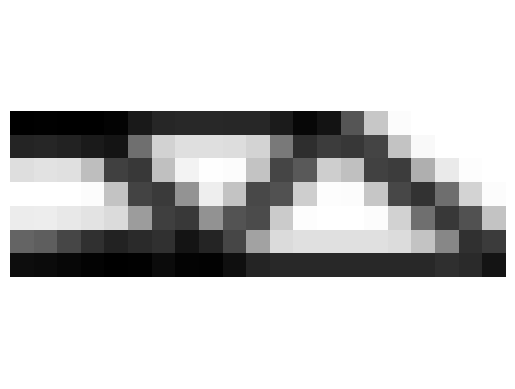

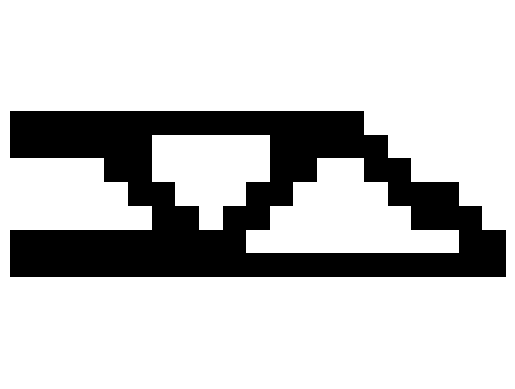

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import time


# ============================================================== #
#  HEAVISIDE PROJECTION（Wang et al. 2011）
#
#  xTilde : 线性过滤后的中间密度场
#  beta   : 投影斜率（越大越接近阶跃函数，建议从 1 开始连续加倍至 512）
#  eta    : 投影阈值（通常取 0.5）
#
#  返回：
#    xPhys  : 投影后密度场
#    dxPhys : 导数 dxPhys/dxTilde（用于链式法则）
# ============================================================== #
def heaviside_proj(xTilde, beta, eta=0.5):
    tanh_eta   = np.tanh(beta * eta)
    tanh_1meta = np.tanh(beta * (1.0 - eta))
    denom      = tanh_eta + tanh_1meta

    xPhys  = (tanh_eta + np.tanh(beta * (xTilde - eta))) / denom
    dxPhys = beta * (1.0 - np.tanh(beta * (xTilde - eta))**2) / denom
    return xPhys, dxPhys


# ============================================================== #
#  MAIN: 2-D TOPOLOGY OPTIMIZATION
#
#  ft = 1 : 灵敏度过滤（sensitivity filter）
#  ft = 2 : 密度过滤（density filter）
#  ft = 3 : 密度过滤 + Heaviside 投影
# ============================================================== #
def top88(nelx, nely, volfrac, penal, rmin, ft=2,
          beta=1.0, eta=0.5, betaIter=50):
    ## ---------------------------------------------------------- ##
    ##  MATERIAL PROPERTIES
    ## ---------------------------------------------------------- ##
    E0   = 1000.0
    Emin = 1e-9
    nu   = 0.3

    ## ---------------------------------------------------------- ##
    ##  ELEMENT STIFFNESS MATRIX
    ## ---------------------------------------------------------- ##
    A11 = np.array([[ 12,  3, -6, -3],
                    [  3, 12,  3,  0],
                    [ -6,  3, 12, -3],
                    [ -3,  0, -3, 12]])
    A12 = np.array([[ -6, -3,  0,  3],
                    [ -3, -6, -3, -6],
                    [  0, -3, -6,  3],
                    [  3, -6,  3, -6]])
    B11 = np.array([[ -4,  3, -2,  9],
                    [  3, -4, -9,  4],
                    [ -2, -9, -4, -3],
                    [  9,  4, -3, -4]])
    B12 = np.array([[  2, -3,  4, -9],
                    [ -3,  2,  9, -2],
                    [  4,  9,  2,  3],
                    [ -9, -2,  3,  2]])
    KE = (1 / (1 - nu**2) / 24) * (
        np.block([[A11, A12], [A12.T, A11]])
        + nu * np.block([[B11, B12], [B12.T, B11]])
    )

    ## ---------------------------------------------------------- ##
    ##  DOF MAP
    ## ---------------------------------------------------------- ##
    nodenrs = np.arange(1, (1+nelx)*(1+nely)+1).reshape(1+nely, 1+nelx, order='F')
    edofVec = (2 * nodenrs[:nely, :nelx] + 1).reshape(nelx*nely, 1, order='F')
    offsets = np.array([0, 1, 2*nely+2, 2*nely+3, 2*nely, 2*nely+1, -2, -1])
    edofMat = (np.tile(edofVec, (1, 8)) + np.tile(offsets, (nelx*nely, 1)) - 1).astype(int)

    iK = np.tile(edofMat, 8).flatten().astype(int)
    jK = np.repeat(edofMat, 8, axis=1).flatten().astype(int)

    ## ---------------------------------------------------------- ##
    ##  LOADS AND SUPPORTS
    ## ---------------------------------------------------------- ##
    ndof = 2 * (nelx+1) * (nely+1)

    F = np.zeros(ndof)
    F[2 * (nelx * (nely + 1) + nely) + 1] = -0.1

    fixeddofs = np.arange(0, 2 * (nely + 1))
    freedofs  = np.setdiff1d(np.arange(ndof), fixeddofs)

    ## ---------------------------------------------------------- ##
    ##  FILTER（线性密度过滤核，ft=1/2/3 共用）
    ## ---------------------------------------------------------- ##
    ceil_rmin = int(np.ceil(rmin))
    nfilter   = nelx * nely * (2*(ceil_rmin-1)+1)**2
    iH = np.zeros(nfilter, dtype=int)
    jH = np.zeros(nfilter, dtype=int)
    sH = np.zeros(nfilter)
    k  = 0
    for i1 in range(1, nelx+1):
        for j1 in range(1, nely+1):
            e1 = (i1-1)*nely + j1 - 1
            for i2 in range(max(i1-(ceil_rmin-1), 1), min(i1+(ceil_rmin-1), nelx)+1):
                for j2 in range(max(j1-(ceil_rmin-1), 1), min(j1+(ceil_rmin-1), nely)+1):
                    e2 = (i2-1)*nely + j2 - 1
                    iH[k] = e1
                    jH[k] = e2
                    sH[k] = max(0.0, rmin - np.sqrt((i1-i2)**2 + (j1-j2)**2))
                    k += 1
    H  = sp.csr_matrix((sH[:k], (iH[:k], jH[:k])), shape=(nelx*nely, nelx*nely))
    Hs = np.asarray(H.sum(axis=1)).flatten()

    ## ---------------------------------------------------------- ##
    ##  INITIALISE
    ## ---------------------------------------------------------- ##
    x      = np.full((nely, nelx), volfrac)
    xPhys  = x.copy()
    U      = np.zeros(ndof)
    loop   = 0
    change = 1.0

    ft_names = {1: 'Sensitivity filter', 2: 'Density filter',
                3: f'Heaviside projection (beta={beta:.1f}, eta={eta})'}
    print(f"\n{'='*60}")
    print(f"  2-D Topology Optimization  |  ft={ft}: {ft_names[ft]}")
    print(f"  nelx={nelx}, nely={nely}  "
          f"|  volfrac={volfrac}  penal={penal}  rmin={rmin}")
    print(f"{'='*60}\n")

    ## ---------------------------------------------------------- ##
    ##  ITERATION LOOP
    ## ---------------------------------------------------------- ##
    while loop < 400 and change>0.001:
        loop += 1

        # ------ beta continuation (ft=3 专用) ------
        # 每隔 betaIter 代将 beta 加倍，上限 512
        if ft == 3 and loop > 1 and loop % betaIter == 1:
            beta = min(beta * 2, 512)
            print(f"  [Heaviside] beta updated -> {beta}")

        # ------ FE-ANALYSIS ------
        elem_mods = Emin + xPhys.flatten(order='F')**penal * (E0 - Emin)
        sK = (KE.flatten(order='F')[:, None] * elem_mods[None, :]).flatten(order='F')
        K  = sp.csr_matrix((sK, (iK, jK)), shape=(ndof, ndof))
        K  = (K + K.T) / 2
        U[freedofs] = spsolve(K[freedofs, :][:, freedofs], F[freedofs])

        # ------ OBJECTIVE & SENSITIVITIES ------
        Ue = U[edofMat]
        ce = (Ue @ KE * Ue).sum(axis=1).reshape(nely, nelx, order='F')
        c  = np.sum((Emin + xPhys**penal * (E0-Emin)) * ce)
        dc = -penal * (E0-Emin) * xPhys**(penal-1) * ce
        dv = np.ones((nely, nelx))

        # ------ FILTERING / PROJECTION ------
        if ft == 1:
            # 灵敏度过滤：对 dc 加权平均，dv 不变
            dc = (H @ (x.flatten(order='F') * dc.flatten(order='F') / Hs)
                  / np.maximum(1e-3, x.flatten(order='F'))
                  ).reshape(nely, nelx, order='F')

        elif ft == 2:
            # 密度过滤：xPhys = H*x/Hs，链式法则传播 dc, dv
            dc = (H @ (dc.flatten(order='F') / Hs)).reshape(nely, nelx, order='F')
            dv = (H @ (dv.flatten(order='F') / Hs)).reshape(nely, nelx, order='F')

        elif ft == 3:
            # Heaviside 投影：两步链式法则
            #   x  --(线性过滤)-->  xTilde  --(Heaviside)-->  xPhys
            #
            # Step 1: 计算 xTilde
            xTilde = (H @ x.flatten(order='F') / Hs).reshape(nely, nelx, order='F')

            # Step 2: 投影梯度 dxPhys/dxTilde
            _, dxProj = heaviside_proj(xTilde, beta, eta)

            # Step 3: 链式法则反向传播至设计变量 x
            dc = (H @ ((dxProj * dc).flatten(order='F') / Hs)).reshape(nely, nelx, order='F')
            dv = (H @ ((dxProj * dv).flatten(order='F') / Hs)).reshape(nely, nelx, order='F')

        # ------ OPTIMALITY CRITERIA UPDATE ------
        l1, l2, move = 0.0, 1e9, 0.2
        while (l2 - l1) / (l1 + l2) > 1e-3:
            lmid = 0.5 * (l1 + l2)
            xnew = np.maximum(0.0, np.maximum(x - move,
                   np.minimum(1.0, np.minimum(x + move,
                   x * np.sqrt(-dc / np.maximum(1e-10, dv) / lmid)))))

            # 计算体积约束对应的 xPhys
            if ft == 1:
                xPhys_tmp = xnew.copy()
            elif ft == 2:
                xPhys_tmp = (H @ xnew.flatten(order='F') / Hs).reshape(nely, nelx, order='F')
            elif ft == 3:
                xTilde_tmp = (H @ xnew.flatten(order='F') / Hs).reshape(nely, nelx, order='F')
                xPhys_tmp, _ = heaviside_proj(xTilde_tmp, beta, eta)

            if xPhys_tmp.sum() > volfrac * nelx * nely:
                l1 = lmid
            else:
                l2 = lmid

        change = np.max(np.abs(xnew - x))
        x      = xnew
        xPhys  = xPhys_tmp

        print(f" It.:{loop:5d}  Obj.:{c:11.7f}  Vol.:{xPhys.mean():7.3f}"
              f"  ch.:{change:7.3f}"
              + (f"  beta:{beta:6.1f}" if ft == 3 else ""))


    ## ---------------------------------------------------------- ##
    ##  PLOT: 连续密度场结果
    ## ---------------------------------------------------------- ##
    plt.figure(1)
    plt.clf()
    plt.imshow(1 - xPhys, cmap='gray', vmin=0, vmax=1)
    plt.axis('equal'); plt.axis('off')
    plt.savefig(f"top88_result_05_147.pdf", dpi=300, bbox_inches='tight')

    ## ---------------------------------------------------------- ##
    ##  POST-PROCESS：二值化结构 compliance
    ## ---------------------------------------------------------- ##
    xBin = (xPhys >= 0.5).astype(float)

    plt.figure(2)
    plt.clf()
    plt.imshow(1 - xBin, cmap='gray', vmin=0, vmax=1)
    plt.axis('equal'); plt.axis('off')
    plt.savefig(f"top88_result_binary_05_147.pdf", dpi=300, bbox_inches='tight')

    elem_mods_bin = Emin + xBin.flatten(order='F')**penal * (E0 - Emin)
    sK_bin = (KE.flatten(order='F')[:, None] * elem_mods_bin[None, :]).flatten(order='F')
    K_bin  = sp.csr_matrix((sK_bin, (iK, jK)), shape=(ndof, ndof))
    K_bin  = (K_bin + K_bin.T) / 2

    U_bin = np.zeros(ndof)
    U_bin[freedofs] = spsolve(K_bin[freedofs, :][:, freedofs], F[freedofs])

    Ue_bin = U_bin[edofMat]
    ce_bin = (Ue_bin @ KE * Ue_bin).sum(axis=1).reshape(nely, nelx, order='F')
    c_bin  = np.sum((Emin + xBin**penal * (E0 - Emin)) * ce_bin)

    print(f"\nBinary volume fraction          : {xBin.mean():.4f}")
    print(f"Binary structure compliance     : {c_bin:.6f}")
    print(f"Optimized compliance (continuous): {c:.6f}")

    return xPhys


# ============================================================== #
#  ENTRY POINT
#
#  ft=1 : 灵敏度过滤
#  ft=2 : 密度过滤
#  ft=3 : 密度过滤 + Heaviside 投影（结果最清晰，推荐）
# ============================================================== #
if __name__ == "__main__":
    t1 = time.time()
    xx = top88(
        nelx=21, nely=7,
        volfrac=0.5, penal=3, rmin=1.5,
        ft=3,           # 使用 Heaviside 投影
        beta=2.0,       # 初始投影斜率
        eta=0.5,        # 投影阈值
        betaIter=400,    # beta 加倍间隔（代数）
    )
    t2 = time.time()
    plt.show()